In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from arch import arch_model

from statsmodels.stats.diagnostic import het_arch

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [3]:
data = pd.read_csv(
    "../data/features.csv",
    index_col=0,
    parse_dates=True
)

data.head()

,Close,Log_Return,Return,SMA20,SMA50,SMA100,SMA200,EMA20,Momentum10,Momentum20,...,Lag2,Lag5,Lag10,Price_SMA20,Price_SMA50,UpperBand,LowerBand,RSI,MACD,MACD_Signal
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-16,24.883137,-0.007358,-0.007331,25.046606,25.176153,26.631793,27.035149,25.013353,0.147905,-0.540051,...,-0.014235,0.023645,0.007274,0.993473,0.988361,25.889497,24.203715,45.695046,-0.136604,-0.159600
2015-10-19,25.037760,0.006195,0.006214,25.007615,25.159167,26.588194,27.039375,25.015677,0.212889,-0.779835,...,0.014861,-0.004649,0.003617,1.001205,0.995174,25.768494,24.246735,59.838000,-0.118958,-0.151471
2015-10-20,25.494896,0.018093,0.018258,25.011760,25.132500,26.552512,27.049294,25.061317,0.551258,0.082909,...,-0.007358,0.001701,0.004773,1.019316,1.014419,25.782752,24.240768,62.073745,-0.067310,-0.134639
2015-10-21,25.492657,-0.000088,-0.000088,25.005486,25.133710,26.516227,27.059191,25.102397,0.667786,-0.125488,...,0.006195,-0.014235,-0.004773,1.019483,1.014281,25.757509,24.253462,65.300136,-0.026256,-0.112962
2015-10-22,25.882586,0.015180,0.015296,25.011088,25.134875,26.485136,27.069389,25.176701,1.344553,0.112059,...,0.018093,0.014861,-0.011622,1.034844,1.029748,25.788357,24.233819,67.534311,0.037312,-0.082907


In [4]:
returns = data["Log_Return"].dropna()

returns.head()

Date
2015-10-16   -0.007358
2015-10-19    0.006195
2015-10-20    0.018093
2015-10-21   -0.000088
2015-10-22    0.015180
Name: Log_Return, dtype: float64

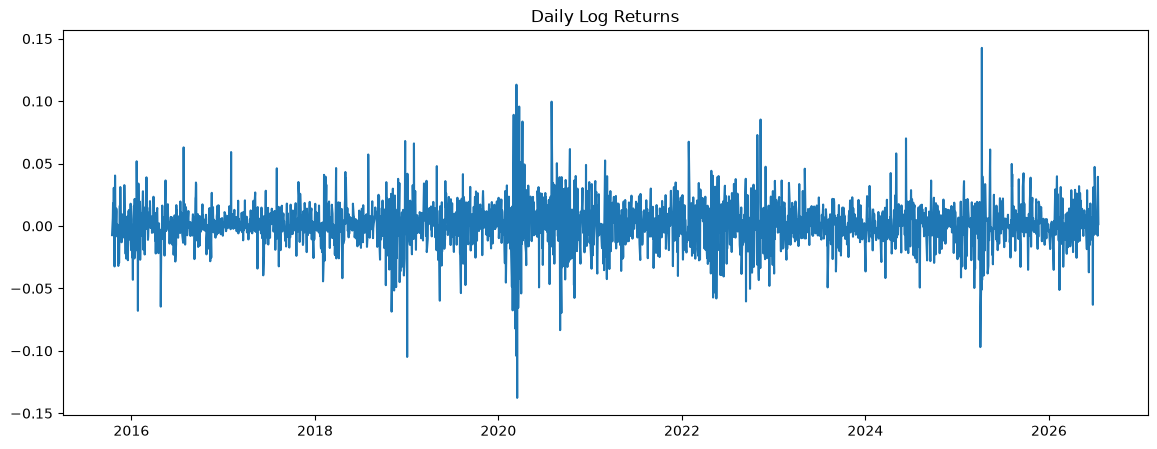

In [5]:
plt.figure(figsize=(14,5))

plt.plot(
    returns
)

plt.title(
    "Daily Log Returns"
)

plt.show()

In [6]:
arch_test = het_arch(
    returns
)

print(
    "LM Statistic:",
    arch_test[0]
)

print(
    "p-value:",
    arch_test[1]
)

LM Statistic: 371.2797002506666
p-value: 1.2064770668414998e-73


In [7]:
split = int(
    len(returns)*0.8
)


train = returns.iloc[:split]

test = returns.iloc[split:]

In [8]:
garch = arch_model(
    train * 100,
    vol="Garch",
    p=1,
    q=1,
    mean="Zero",
    dist="normal"
)


garch_fit = garch.fit(
    disp="off"
)


garch_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                       Zero Mean - GARCH Model Results                        
==============================================================================
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4148.58
Distribution:                  Normal   AIC:                           8303.15
Method:            Maximum Likelihood   BIC:                           8320.19
                                        No. Observations:                 2161
Date:                Sun, Jul 19 2026   Df Residuals:                     2161
Time:                        23:37:46   Df Model:                            0
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1324  4.756e-02      2.784  5.363e-03 [3.921e-02,  0.226]
alpha[1]       0.0921  2.073e-02      4.443  8.866e-06 [5.148e-02,  0.133]
beta[1]        0.8656  3.015e-02     28.707 3.131e-181   [  0.807,  0.925]
==========================================================================

Covariance estimator: robust
"""

In [9]:
forecast = garch_fit.forecast(
    horizon=len(test)
)

In [10]:
variance_forecast = (
    forecast
    .variance
    .iloc[-1]
)


vol_forecast = np.sqrt(
    variance_forecast
)


vol_forecast.head()

h.001    1.556245
h.002    1.565878
h.003    1.575049
h.004    1.583782
h.005    1.592101
Name: 2024-05-17 00:00:00, dtype: float64

In [11]:
realized_vol = (
    test
    .rolling(20)
    .std()
    *100
)

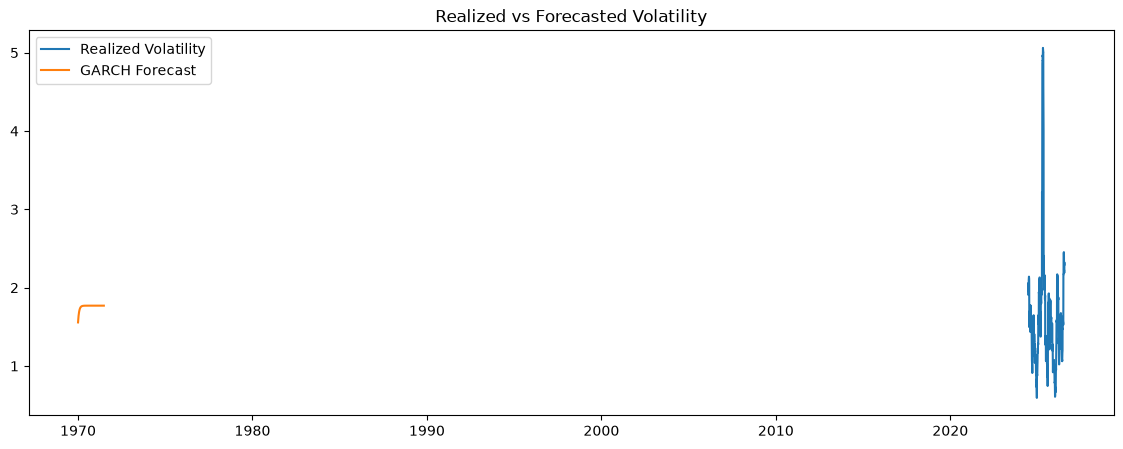

In [14]:
plt.figure(figsize=(14,5))


plt.plot(
    realized_vol,
    label="Realized Volatility"
)


plt.plot(
    vol_forecast.values,
    label="GARCH Forecast"
)


plt.legend()

plt.title(
    "Realized vs Forecasted Volatility"
)


plt.show()

In [13]:
comparison = pd.DataFrame({

    "Realized":
    realized_vol.dropna().values,

    "Forecast":
    vol_forecast.values[
        -len(realized_vol.dropna()):
    ]

})


comparison.head()

,Realized,Forecast
0,1.914257,1.679361
1,1.954584,1.683299
2,2.048417,1.687062
3,2.058393,1.690658
4,1.970021,1.694094


In [15]:
rmse = np.sqrt(
    mean_squared_error(
        comparison["Realized"],
        comparison["Forecast"]
    )
)


mae = mean_absolute_error(
    comparison["Realized"],
    comparison["Forecast"]
)


print(
    "Volatility RMSE:",
    rmse
)

print(
    "Volatility MAE:",
    mae
)

Volatility RMSE: 0.7880521101871266
Volatility MAE: 0.5299455022812852


In [16]:
garch_results = {
    "ARCH_p_value": 1.206e-73,
    "Volatility_RMSE": 0.7881,
    "Volatility_MAE": 0.5299
}